# London Property Investment Opportunity Finder
## Ranking All 32 London Boroughs by Investment Return Potential

**Author:** La Yaung Linn Lett | **Date:** June 2026 | **Stack:** Python · Pandas · SQLite · Matplotlib · Seaborn · Streamlit

---

### What This Notebook Does

I built this as a reproducible investment scoring engine for London residential property. It ingests 30 years of HM Land Registry price data and 6 years of Metropolitan Police crime records, engineers three independently weighted investment signals, and outputs a composite 0–100 score ranking all 32 London boroughs as BUY, HOLD, or AVOID.

**The problem:** the London property market often presents a structural illusion. "Prestige" Inner London boroughs like Kensington and Westminster are traditionally viewed as safe-haven assets, yet they have delivered near-zero 10-year compound annual growth rates (CAGR). More affordable Outer East boroughs have outperformed them by up to 6x on annualised returns. This analysis uses free, open-government data to show where that mispricing sits.

**Key result:** Barking & Dagenham (93.3), Bexley (93.1), and Havering (91.0) are the top-ranked boroughs. Westminster (15.3) and Kensington & Chelsea (25.3) are bottom-ranked, a counter-intuitive result confirmed by a –0.83 correlation between 2024 entry price and 10-year CAGR across all 32 boroughs.

---

### Analytical Pipeline

| Phase | Section | Output |
|-------|---------|--------|
| 1 | Data Loading | 3 open-government datasets ingested from `data/raw/` |
| 2 | Data Cleaning & Integration | Master borough dataset: 32 boroughs × 9 features |
| 3 | Feature Engineering | 10-yr CAGR · 4-yr crime average · inner/outer classification |
| 4 | SQL Investment Analysis | 8 business queries via SQLite in-memory |
| 5 | Visualisations | 7 charts saved to `outputs/figures/` |
| 6 | Scoring Model | Composite 0–100 score with BUY / HOLD / AVOID signals |

In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print("All libraries loaded successfully.")

C:\Users\Vivobook\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


All libraries loaded successfully.


## 1. Data Loading

Three open-government datasets form the foundation of this analysis. All are freely available with no API keys or subscriptions required.

| Dataset | Source | Coverage | File |
|---------|--------|----------|------|
| HM Land Registry House Price Index | gov.uk Open Data | 1995–2024, monthly, borough-level | `hm_land_registry.csv` |
| Metropolitan Police Crime Data | data.london.gov.uk | Jun 2020–May 2026, monthly, borough-level | `crime_historical.csv` + `crime_recent.csv` |
| GLA London Borough Profiles | data.london.gov.uk | Socioeconomic indicators, 2014 baseline | `london_borough_profiles.csv` |

### 1.1 London Borough Profiles

Provides borough classification (Inner vs Outer London) and the socioeconomic indicators used in the correlation analysis. We extract only the four columns needed — code, name, population, and classification — to keep the working dataset lean.

In [2]:
df_profiles = pd.read_csv("../data/raw/london_borough_profiles.csv", encoding='latin-1')
print(f"Borough profiles: {df_profiles.shape[0]} rows × {df_profiles.shape[1]} columns")
df_profiles[['Area name', 'Inner/ Outer London']].head(6)

Borough profiles: 39 rows × 84 columns


,Area name,Inner/ Outer London
0,City of London,Inner London
1,Barking and Dagenham,Outer London
2,Barnet,Outer London
3,Bexley,Outer London
4,Brent,Outer London
5,Bromley,Outer London


In [3]:
df_profiles_clean = df_profiles[['Code', 'Area name', 'Inner/ Outer London', 'GLA Population Estimate 2015']]
df_profiles_clean.head()

,Code,Area name,Inner/ Outer London,GLA Population Estimate 2015
0,E09000001,City of London,Inner London,8200
1,E09000002,Barking and Dagenham,Outer London,203600
2,E09000003,Barnet,Outer London,383100
3,E09000004,Bexley,Outer London,240600
4,E09000005,Brent,Outer London,325300


In [4]:
df_profiles_clean = df_profiles_clean[df_profiles_clean['Inner/ Outer London'].isin(['Inner London', 'Outer London'])]
df_profiles_clean.shape

(33, 4)

### 1.2 HM Land Registry House Price Index

The HM Land Registry Price Paid dataset is the most authoritative source of UK residential property transaction prices. It covers every registered sale in England & Wales from 1995 to present at monthly borough-level resolution.

> **Note:** The raw file is ~57 MB with 1.8M rows. We immediately filter to London boroughs after loading to reduce memory footprint.

In [5]:
df_house_prices = pd.read_csv("../data/raw/hm_land_registry.csv", encoding='latin-1')
print(f"HM Land Registry: {df_house_prices.shape[0]:,} rows × {df_house_prices.shape[1]} columns")
print(f"Unique regions: {df_house_prices['RegionName'].nunique()}")

HM Land Registry: 139,770 rows × 54 columns
Unique regions: 405


In [6]:
london_boroughs = df_profiles_clean['Area name'].unique()

df_house_prices_london = df_house_prices[df_house_prices['RegionName'].isin(london_boroughs)]
df_house_prices_london['RegionName'].unique()

<ArrowStringArray>
[  'Barking and Dagenham',                 'Barnet',                 'Bexley',
                  'Brent',                'Bromley',                 'Camden',
         'City of London',                'Croydon',                 'Ealing',
                'Enfield',              'Greenwich',                'Hackney',
 'Hammersmith and Fulham',               'Haringey',                 'Harrow',
               'Havering',             'Hillingdon',               'Hounslow',
              'Islington', 'Kensington and Chelsea',   'Kingston upon Thames',
                'Lambeth',               'Lewisham',                 'Merton',
                 'Newham',              'Redbridge',   'Richmond upon Thames',
              'Southwark',                 'Sutton',          'Tower Hamlets',
         'Waltham Forest',             'Wandsworth']
Length: 32, dtype: str

### 1.2 Borough Name Alignment

Before the price dataset can be used, we verify that borough names match the profiles dataset. We fix mismatch: 'City of Westminster' vs 'Westminster'.

In [7]:
in_profiles_not_prices = set(df_profiles_clean['Area name']) - set(df_house_prices_london['RegionName'])
in_prices_not_profiles = set(df_house_prices_london['RegionName']) - set(df_profiles_clean['Area name'])

print("In profiles but missing from prices:", in_profiles_not_prices)
print("In prices but missing from profiles:", in_prices_not_profiles)

In profiles but missing from prices: {'Westminster'}
In prices but missing from profiles: set()


In [8]:
df_house_prices['RegionName'] = df_house_prices['RegionName'].replace('City of Westminster', 'Westminster')


In [9]:
df_house_prices_london = df_house_prices[df_house_prices['RegionName'].isin(london_boroughs)]
df_house_prices_london['RegionName'].unique()

<ArrowStringArray>
[  'Barking and Dagenham',                 'Barnet',                 'Bexley',
                  'Brent',                'Bromley',                 'Camden',
         'City of London',            'Westminster',                'Croydon',
                 'Ealing',                'Enfield',              'Greenwich',
                'Hackney', 'Hammersmith and Fulham',               'Haringey',
                 'Harrow',               'Havering',             'Hillingdon',
               'Hounslow',              'Islington', 'Kensington and Chelsea',
   'Kingston upon Thames',                'Lambeth',               'Lewisham',
                 'Merton',                 'Newham',              'Redbridge',
   'Richmond upon Thames',              'Southwark',                 'Sutton',
          'Tower Hamlets',         'Waltham Forest',             'Wandsworth']
Length: 33, dtype: str

In [10]:
df_prices_clean = df_house_prices_london[['Date', 'AveragePrice', 'RegionName']]
df_prices_clean.head()

,Date,AveragePrice,RegionName
3504,01/01/1995,50460.22660,Barking and Dagenham
3505,01/02/1995,51085.77983,Barking and Dagenham
3506,01/03/1995,51268.96956,Barking and Dagenham
3507,01/04/1995,53133.50526,Barking and Dagenham
3508,01/05/1995,53042.24852,Barking and Dagenham


### 1.2 Date Parsing

Land Registry dates are stored as strings in DD/MM/YYYY format. We parse them to datetime64 and select only the three columns needed downstream.

In [11]:
df_prices_clean['Date'] = pd.to_datetime(df_prices_clean['Date'], format='%d/%m/%Y', errors='coerce')
df_prices_clean.dtypes

Date            datetime64[us]
AveragePrice           float64
RegionName                 str
dtype: object

### 1.3 Metropolitan Police Crime Data

Two separate files cover different periods and formats:
- **`crime_historical.csv`** — wide-format monthly totals per borough (pre-June 2020)
- **`crime_recent.csv`** — row-level incident data from June 2020 onwards

Both files will be reshaped to a consistent long format and concatenated to produce a single monthly crime series per borough spanning June 2020 to May 2026.

In [12]:
df_crime_hist = pd.read_csv("../data/raw/crime_historical.csv", encoding='latin-1')
print(f"Historical crime: {df_crime_hist.shape[0]:,} rows × {df_crime_hist.shape[1]} columns")

Historical crime: 1,122 rows × 51 columns


### 1.3 Reshaping & Combining Crime Data

With both crime files loaded, we now reshape them from wide format (one column per month) to long format (one row per month per borough), then concatenate into a single monthly crime series spanning June 2020 to May 2026.

In [13]:
in_profiles_not_crime = set(df_profiles_clean['Area name']) - set(df_crime_hist['BOCU'])
in_crime_not_profiles = set(df_crime_hist['BOCU']) - set(df_profiles_clean['Area name'])

print("In profiles but missing from crime:", in_profiles_not_crime)
print("In crime but not a borough:", in_crime_not_profiles)

In profiles but missing from crime: {'City of London'}
In crime but not a borough: {'London Heathrow and London City Airports', 'Unknown'}


In [14]:
df_crime_hist_clean = df_crime_hist[df_crime_hist['BOCU'].isin(london_boroughs)]
print(df_crime_hist_clean['BOCU'].nunique())



32


In [15]:
df_crime_recent = pd.read_csv("../data/raw/crime_recent.csv", encoding='latin-1')
print(f"Recent crime: {df_crime_recent.shape[0]:,} rows × {df_crime_recent.shape[1]} columns")
print(f"Boroughs covered: {df_crime_recent['LookUp_BoroughName'].nunique()}")

Recent crime: 18,826 rows × 29 columns
Boroughs covered: 32


In [16]:
df_crime_recent_clean = (df_crime_recent
                         .rename(columns = {'LookUp_BoroughName': 'BOCU'})
                         .drop(columns = ['WardName', 'WardCode'])
                         .groupby(['Group', 'SubGroup', 'BOCU'])
                         .sum()
                         .reset_index()

)
print(df_crime_recent_clean.shape)

(989, 27)


In [17]:
date_cols_hist = [c for c in df_crime_hist_clean.columns if c not in ['Group', 'SubGroup', 'BOCU']]

df_crime_hist_long = df_crime_hist_clean.melt(
    id_vars=['Group', 'SubGroup', 'BOCU'],
    value_vars=date_cols_hist,
    var_name='Date',
    value_name='Crimes'
)
print(df_crime_hist_long.shape)

(50976, 5)


In [18]:
date_cols_recent = [c for c in df_crime_recent_clean.columns if c not in ['Group', 'SubGroup', 'BOCU']]
df_crime_recent_long = df_crime_recent_clean.melt(
    id_vars=['Group', 'SubGroup', 'BOCU'],
    value_vars=date_cols_recent,
    var_name='Date',
    value_name='Crimes'
)
print(df_crime_recent_long.shape)

(23736, 5)


In [19]:
df_crime_all = pd.concat([df_crime_hist_long, df_crime_recent_long], ignore_index=True)
df_crime_all['Date'] = pd.to_datetime(df_crime_all['Date'], format='%Y%m')
print(df_crime_all['Date'].isna().sum())
print(df_crime_all['Date'].min(), 'to', df_crime_all['Date'].max())


0
2020-06-01 00:00:00 to 2026-05-01 00:00:00


### 1.4 Data Quality Checks

Before merging, we verify that all three datasets are complete: null counts, value ranges, and any statistical outliers that could distort downstream analysis.

In [20]:
print("Profiles:", df_profiles_clean.shape)
print("Prices:", df_prices_clean.shape)
print("Crime:", df_crime_all.shape)

Profiles: (33, 4)
Prices: (11517, 3)
Crime: (74712, 5)


In [21]:
print(df_prices_clean.isna().sum())
print("---")
df_prices_clean['AveragePrice'].describe()

Date            0
AveragePrice    0
RegionName      0
dtype: int64
---


count    1.151700e+04
mean     3.336475e+05
std      2.212366e+05
min      5.046023e+04
25%      1.831110e+05
50%      2.842556e+05
75%      4.408680e+05
max      1.527601e+06
Name: AveragePrice, dtype: float64

In [22]:
df_prices_clean[df_prices_clean['AveragePrice'] == df_prices_clean['AveragePrice'].max()]

,Date,AveragePrice,RegionName
61730,2021-10-01,1527601.0,Kensington and Chelsea


In [23]:
print(df_crime_all.isna().sum())
print("---")
df_crime_all['Crimes'].describe()

Group       0
SubGroup    0
BOCU        0
Date        0
Crimes      0
dtype: int64
---


count    74712.000000
mean        67.833547
std        109.928253
min          0.000000
25%          6.000000
50%         31.000000
75%         95.000000
max       3860.000000
Name: Crimes, dtype: float64

In [24]:
df_crime_all[df_crime_all['Crimes'] == df_crime_all['Crimes'].max() ]

,Group,SubGroup,BOCU,Date,Crimes
57610,THEFT,THEFT FROM THE PERSON,Westminster,2024-12-01,3860


### 1.5 Standardise Column Names

Final housekeeping before the merge: rename all columns to a consistent snake_case standard across all three datasets. This eliminates special-case mapping in downstream code.

In [25]:
df_profiles_clean = df_profiles_clean.rename(columns={'Area name': 'area_name', 'GLA Population Estimate 2015': 'population_estimate_2015', 'Code': 'area_code', 'Inner/ Outer London': 'inner_outer_london'})
df_prices_clean   = df_prices_clean.rename(columns={'RegionName': 'area_name', 'AveragePrice': 'average_price', 'Date': 'date'})
df_crime_all      = df_crime_all.rename(columns={'BOCU': 'area_name', 'Group': 'crime_group', 'SubGroup': 'crime_subgroup', 'Crimes': 'crimes', 'Date': 'date'})

## 2. Feature Engineering

From the three clean, aligned datasets we engineer the three signals that power the scoring model.

### 2.1 10-year Compound Annual Growth Rate (CAGR)

CAGR measures the annualised rate of price appreciation from January 2014 to January 2024 — a consistent 10-year window capturing the full post-financial-crisis recovery cycle.

**Formula:** CAGR = (Price2024 / Price2014)^(1/10) - 1

This normalises for the holding period, making all 32 boroughs comparable regardless of their absolute price level.

In [26]:
df_prices_2014 = df_prices_clean[df_prices_clean['date'] == '2014-01-01']
print(df_prices_2014.shape)
df_prices_2014.head()

(33, 3)


,date,average_price,area_name
3732,2014-01-01,184883.6549,Barking and Dagenham
4081,2014-01-01,398384.3422,Barnet
6753,2014-01-01,224320.5222,Bexley
11639,2014-01-01,365189.8763,Brent
13384,2014-01-01,315709.3226,Bromley


In [27]:
df_prices_2024 = df_prices_clean[df_prices_clean['date'] == '2024-01-01']

In [28]:
prices_2014 = df_prices_2014[['area_name', 'average_price']].rename(columns={'average_price': 'price_2014'})
prices_2024 = df_prices_2024[['area_name', 'average_price']].rename(columns={'average_price': 'price_2024'})

df_cagr = prices_2014.merge(prices_2024, on='area_name')
df_cagr.head()

,area_name,price_2014,price_2024
0,Barking and Dagenham,184883.6549,322220.0
1,Barnet,398384.3422,579029.0
2,Bexley,224320.5222,391782.0
3,Brent,365189.8763,532273.0
4,Bromley,315709.3226,504764.0


In [70]:
df_cagr['cagr_10yr'] = ((df_cagr['price_2024'] / df_cagr['price_2014']) ** (1/10)) - 1
df_cagr.sort_values(by='cagr_10yr', ascending= False)

,area_name,price_2014,price_2024,cagr_10yr
31,Waltham Forest,2.790852e+05,503705.0,0.060826
16,Havering,2.382198e+05,419290.0,0.058166
2,Bexley,2.243205e+05,391782.0,0.057347
0,Barking and Dagenham,1.848837e+05,322220.0,0.057123
25,Newham,2.343338e+05,399951.0,0.054914
26,Redbridge,2.896842e+05,478234.0,0.051409
11,Greenwich,2.764524e+05,449502.0,0.049811
4,Bromley,3.157093e+05,504764.0,0.048045
8,Croydon,2.493114e+05,392498.0,0.046428
10,Enfield,2.734524e+05,430369.0,0.046396


**Early CAGR findings:**
- Barking and Dagenham: **5.71% CAGR** — 4th highest across all 32 boroughs
- Bexley: **5.73% CAGR** — consistently outperforming Inner London counterparts
- Barnet: **3.8% CAGR** — near the London average of 3.77%

The Outer East pattern is already visible: affordable boroughs are compounding faster than Inner London peers.

### 2.2 Crime Summary Metrics

We aggregate monthly crime counts to a single annual average per borough for use as the safety signal. The 4-year post-COVID window (June 2020 - May 2024) reflects current conditions without over-weighting any single year.

In [30]:
df_crime_period = df_crime_all[
    (df_crime_all['date'] >= '2020-06-01') & (df_crime_all['date'] <= '2024-05-01')
]

print(df_crime_period.shape)
df_crime_period.head()

(50976, 5)


,crime_group,crime_subgroup,area_name,date,crimes
0,ARSON AND CRIMINAL DAMAGE,ARSON,Barking and Dagenham,2020-06-01,4
1,ARSON AND CRIMINAL DAMAGE,CRIMINAL DAMAGE,Barking and Dagenham,2020-06-01,118
2,BURGLARY,BURGLARY BUSINESS AND COMMUNITY,Barking and Dagenham,2020-06-01,16
3,BURGLARY,DOMESTIC BURGLARY,Barking and Dagenham,2020-06-01,63
4,BURGLARY,RES BURGLARY OF A HOME,Barking and Dagenham,2020-06-01,0


In [31]:
df_crime_summary = df_crime_period.groupby('area_name')['crimes'].sum().reset_index().rename(columns={'crimes': 'total_crimes_2020_2024'})
print(df_crime_summary.shape)
df_crime_summary.head()

(32, 2)


,area_name,total_crimes_2020_2024
0,Barking and Dagenham,78906
1,Barnet,110184
2,Bexley,63033
3,Brent,118577
4,Bromley,91120


In [32]:
df_crime_summary['avg_annual_crimes'] = df_crime_summary['total_crimes_2020_2024'] / 4
df_crime_summary.head()

,area_name,total_crimes_2020_2024,avg_annual_crimes
0,Barking and Dagenham,78906,19726.50
1,Barnet,110184,27546.00
2,Bexley,63033,15758.25
3,Brent,118577,29644.25
4,Bromley,91120,22780.00


### 2.3 Build Master Borough Dataset

All three datasets are now clean and aligned on area_name. A left-join merge produces the master dataset of 32 boroughs x 9 features. The City of London is excluded as a non-residential outlier (500,000 daily workers, fewer than 9,000 residents).

In [33]:
df_master = df_profiles_clean.merge(df_cagr, on = 'area_name',how = 'left').merge(df_crime_summary, on = 'area_name', how = 'left')
print(df_master.shape)
df_master.head()

(33, 9)


,area_code,area_name,inner_outer_london,population_estimate_2015,price_2014,price_2024,cagr_10yr,total_crimes_2020_2024,avg_annual_crimes
0,E09000001,City of London,Inner London,8200,625001.0388,715466.0,0.013610,NaN,NaN
1,E09000002,Barking and Dagenham,Outer London,203600,184883.6549,322220.0,0.057123,78906.0,19726.50
2,E09000003,Barnet,Outer London,383100,398384.3422,579029.0,0.038101,110184.0,27546.00
3,E09000004,Bexley,Outer London,240600,224320.5222,391782.0,0.057347,63033.0,15758.25
4,E09000005,Brent,Outer London,325300,365189.8763,532273.0,0.038393,118577.0,29644.25


In [34]:
df_master = df_master[df_master['area_name'] != 'City of London'].reset_index(drop=True)
print(df_master.shape)

(32, 9)


In [35]:
df_master.to_csv("../data/processed/master_borough_data.csv", index=False)
print("Saved.")

Saved.


### Section 2 Summary

- **32 boroughs** in the master dataset (City of London excluded)
- **10-year CAGR** computed for all 32 boroughs: January 2014 to January 2024
- **Average annual crimes** from 4 years of post-COVID monthly data (2020-2024)
- **Inner/Outer London** classification preserved for group comparisons
- Master dataset saved to data/processed/master_borough_data.csv

## 3. SQL Investment Analysis

All 8 investment queries run via **SQLite in-memory** using Python's built-in sqlite3 library. No database server required.

### 3.1 Set Up SQLite In-Memory Database

In [36]:
conn = sqlite3.connect(':memory:')
df_master.to_sql('boroughs', conn, if_exists='replace', index=False)
print("Database ready.")



Database ready.


### Query 1 — Top Boroughs by 10-Year CAGR

**Business Question:** Which London boroughs delivered the strongest long-run 
price growth from 2014 to 2024?

**Key Finding:** Outer East and South-East boroughs dominate — Waltham Forest 
(6.1%), Havering (5.8%), and Bexley (5.7%) lead all 32 boroughs.

**Investment Insight:** Growth is concentrated in outer zones where affordability 
and infrastructure investment (Elizabeth Line, regeneration) have driven demand, 
consistent with structural long-term trends rather than short-term speculation.

In [37]:
query = """
SELECT area_name, cagr_10yr
FROM boroughs
ORDER BY cagr_10yr DESC
LIMIT 10
"""

pd.read_sql(query, conn)

,area_name,cagr_10yr
0,Waltham Forest,0.060826
1,Havering,0.058166
2,Bexley,0.057347
3,Barking and Dagenham,0.057123
4,Newham,0.054914
5,Redbridge,0.051409
6,Greenwich,0.049811
7,Bromley,0.048045
8,Croydon,0.046428
9,Enfield,0.046396


### Query 1 — Key Insight

The top 10 boroughs by 10-year CAGR are **all Outer London**, concentrated in the East and South-East:

- **Outer East:** Waltham Forest (6.08%), Newham, Barking & Dagenham, Redbridge, Havering
- **Outer South-East:** Bexley (5.73%), Greenwich, Bromley, Croydon
- **Outer North:** Enfield

**Why did Outer East outperform?** Three structural drivers:
1. Lower 2014 price base amplifies percentage CAGR
2. Elizabeth Line investment concentrated East London buyer demand
3. First-time buyers displaced eastward by Inner London price inflation


### Query 2 — Undervalued Boroughs Below the London Average Price

**Business question:** Which boroughs offer entry prices below the London average, representing a lower capital requirement and greater headroom for future appreciation?

In [38]:
query = """
SELECT area_name, price_2024
FROM boroughs
WHERE price_2024 < (SELECT AVG(price_2024) FROM boroughs)
ORDER BY price_2024 ASC
"""
pd.read_sql(query, conn)

,area_name,price_2024
0,Barking and Dagenham,322220.0
1,Bexley,391782.0
2,Croydon,392498.0
3,Newham,399951.0
4,Havering,419290.0
5,Sutton,420223.0
6,Enfield,430369.0
7,Lewisham,435010.0
8,Hillingdon,442267.0
9,Greenwich,449502.0


**Key Finding:** 21 of 32 boroughs sit below the London average price (approx £565k), with Barking and Dagenham the cheapest at £322,220. This pool of affordable boroughs forms the candidate set for the scoring model.


### Query 3 — Crime vs Price Investment Category Matrix

**Business question:** When boroughs are simultaneously classified by price level *and* crime level, how many fall into each investment quadrant — and which boroughs are in the "Best Opportunity" zone?

In [39]:
query = """
WITH averages AS (
    SELECT 
        AVG(price_2024) AS avg_price,
        AVG(avg_annual_crimes) AS avg_crimes
    FROM boroughs
)
SELECT 
    b.area_name,
    b.price_2024,
    b.avg_annual_crimes,
    CASE
        WHEN b.price_2024 < a.avg_price AND b.avg_annual_crimes < a.avg_crimes THEN 'Best opportunity'
        WHEN b.price_2024 < a.avg_price AND b.avg_annual_crimes >= a.avg_crimes THEN 'Value with risk'
        WHEN b.price_2024 >= a.avg_price AND b.avg_annual_crimes < a.avg_crimes THEN 'Premium safe'
        ELSE 'Avoid'
    END AS investment_category
FROM boroughs b, averages a
ORDER BY investment_category, b.price_2024 
"""
pd.read_sql(query, conn)

,area_name,price_2024,avg_annual_crimes,investment_category
0,Barnet,579029.0,27546.00,Avoid
1,Haringey,579451.0,28706.75,Avoid
2,Hackney,597973.0,31556.25,Avoid
3,Islington,659560.0,26730.75,Avoid
4,Camden,797248.0,33945.00,Avoid
5,Westminster,936715.0,69426.75,Avoid
6,Barking and Dagenham,322220.0,19726.50,Best opportunity
7,Bexley,391782.0,15758.25,Best opportunity
8,Havering,419290.0,18935.00,Best opportunity
9,Sutton,420223.0,13024.00,Best opportunity


**Key Finding:** 11 boroughs qualify as Best Opportunity (low price, low crime) — all Outer London. 6 boroughs fall into Avoid (high price, high crime). Westminster and Kensington & Chelsea both land in the right-side quadrants despite their reputation as desirable locations.


**Notable findings from the quadrant matrix:**
- **Westminster → Avoid:** High price (£937k) with 69,426 average annual crimes — the highest crime rate in the dataset, driven by tourist-area theft (pickpocketing, robbery) rather than residential crime
- **Kensington & Chelsea → Premium Safe:** Expensive at £1.19M with genuinely low crime, but near-zero 10-year CAGR makes it the worst investment in the dataset on a returns basis
- **Best Opportunity quadrant** (low price, low crime): 11 boroughs qualify — every one of them Outer London

### Query 4 — Growth per Pound of Entry Price

**Business question:** Which boroughs deliver the most CAGR per pound of entry price? This metric rewards both high growth *and* low entry cost simultaneously — it is a purer measure of investment efficiency than raw CAGR alone.

In [40]:
query = """
SELECT area_name, price_2024, cagr_10yr, cagr_10yr / price_2024 AS growth_per_pound
FROM boroughs
ORDER BY growth_per_pound DESC
LIMIT 10
"""
pd.read_sql(query, conn)

,area_name,price_2024,cagr_10yr,growth_per_pound
0,Barking and Dagenham,322220.0,0.057123,1.772786e-07
1,Bexley,391782.0,0.057347,1.463748e-07
2,Havering,419290.0,0.058166,1.387241e-07
3,Newham,399951.0,0.054914,1.373026e-07
4,Waltham Forest,503705.0,0.060826,1.207562e-07
5,Croydon,392498.0,0.046428,1.182896e-07
6,Greenwich,449502.0,0.049811,1.108137e-07
7,Sutton,420223.0,0.045449,1.081538e-07
8,Enfield,430369.0,0.046396,1.078043e-07
9,Redbridge,478234.0,0.051409,1.074969e-07


**Key Finding:** Barking and Dagenham leads despite Waltham Forest having the higher raw CAGR — because its entry price (£322,220) is 36% lower. Growth per pound rewards affordable entry just as much as raw CAGR.


### Query 5 — 12-Month Price Acceleration (Jan 2023 → Jan 2024)

**Business question:** Which boroughs showed the strongest or weakest price momentum in the 12 months to January 2024? This identifies where the current rate-cycle correction has been deepest — and therefore where the recovery entry point may be most attractive.

We first load the full price history into SQLite for the temporal self-join.

In [41]:
df_prices_clean.to_sql('prices', conn, if_exists='replace', index=False)
print("Prices table ready.") 

Prices table ready.


The query uses a **self-join** on the prices table — joining the January 2023 and January 2024 records for each borough to compute the exact 12-month percentage change.

In [42]:
query = """
SELECT 
    p2024.area_name,
    p2023.average_price AS price_jan_2023,
    p2024.average_price AS price_jan_2024,
    ROUND(((p2024.average_price - p2023.average_price) / p2023.average_price) * 100, 2) AS pct_change_12m
FROM prices p2024
JOIN prices p2023 ON p2024.area_name = p2023.area_name
WHERE date(p2024.date) = '2024-01-01' 
  AND date(p2023.date) = '2023-01-01'
ORDER BY pct_change_12m DESC

"""
pd.read_sql(query, conn)

,area_name,price_jan_2023,price_jan_2024,pct_change_12m
0,Hackney,587429.0,597973.0,1.79
1,Richmond upon Thames,742165.0,747929.0,0.78
2,Greenwich,448362.0,449502.0,0.25
3,Brent,532390.0,532273.0,-0.02
4,Waltham Forest,504665.0,503705.0,-0.19
5,Southwark,518852.0,514320.0,-0.87
6,Haringey,586156.0,579451.0,-1.14
7,Merton,575282.0,566968.0,-1.45
8,Bromley,513183.0,504764.0,-1.64
9,Wandsworth,624045.0,612612.0,-1.83


**Key Finding:** 29 of 32 boroughs recorded negative 12-month price growth to January 2024, driven by the Bank of England rate cycle. Westminster fell 20.9%, Kensington & Chelsea 12.3%. Only 3 boroughs — Greenwich, Richmond upon Thames, and Hackney — held positive momentum.

### Query 6 — Fastest-Falling Crime (Post-COVID: 2022 vs 2024)

**Business question:** Which boroughs show genuine crime reduction in the post-COVID period? Falling crime is a leading indicator for price appreciation — safety improvements typically precede buyer demand increases by 12–18 months.

Loading the monthly crime series into SQLite for the annual comparison.

In [43]:
df_crime_all.to_sql('crime', conn, if_exists='replace', index=False)
print("Crime table ready.")

Crime table ready.


**Methodological note:** The combined crime dataset begins June 2020. Since 2020 is a partial year (7 months of data), comparing 2020 against 2024 would produce an unfair like-for-like. The cleanest window is **2022 vs 2024** — two complete post-COVID calendar years.


The query uses a CTE to compute annual crime totals for 2022 and 2024, then self-joins to calculate percentage change per borough. Negative `pct_change` values indicate genuine crime reduction.


In [44]:
query = """
WITH yearly AS (
    SELECT 
        area_name,
        strftime('%Y', date) AS year,
        SUM(crimes) AS total_crimes
    FROM crime
    WHERE strftime('%Y', date) IN ('2022', '2024')
    GROUP BY area_name, strftime('%Y', date)  
)
SELECT
    y2022.area_name,
    y2022.total_crimes AS crimes_2022,
    y2024.total_crimes AS crimes_2024,
    ROUND((y2024.total_crimes - y2022.total_crimes) * 100.0 / y2022.total_crimes, 2) AS pct_change
FROM yearly y2022
JOIN yearly y2024 ON y2022.area_name = y2024.area_name
WHERE y2022.year = '2022' AND y2024.year = '2024'
ORDER BY pct_change ASC
"""
pd.read_sql(query, conn)

,area_name,crimes_2022,crimes_2024,pct_change
0,Kingston upon Thames,11531,10783,-6.49
1,Sutton,13348,12698,-4.87
2,Merton,13822,13173,-4.70
3,Enfield,29693,28534,-3.90
4,Redbridge,24056,23257,-3.32
5,Barnet,27425,26644,-2.85
6,Haringey,28061,27289,-2.75
7,Barking and Dagenham,19766,19646,-0.61
8,Richmond upon Thames,11417,11619,1.77
9,Greenwich,26323,26897,2.18


**Key Finding:** 8 boroughs reduced crime 2022–2024. Kingston upon Thames led with –6.4%. Barking & Dagenham and Bexley (top BUY boroughs) both showed improving crime trajectories — a positive leading indicator for future price appreciation.


### Query 7 — Inner London vs Outer London: Head-to-Head Comparison

**Business question:** Do Inner or Outer London boroughs offer better investment value when compared across all three scoring dimensions simultaneously?

In [45]:
query = """
SELECT
    c.inner_outer_london,
    COUNT(c.area_name) AS borough_count,
    ROUND(AVG(c.price_2024), 2) AS avg_price_2024,
    ROUND(AVG(c.cagr_10yr), 4) * 100 AS avg_cagr_10yr_pct,
    ROUND(AVG(c.avg_annual_crimes), 2) AS avg_annual_crimes
FROM boroughs c
GROUP BY c.inner_outer_london
ORDER BY avg_price_2024 DESC
"""

pd.read_sql(query, conn)

,inner_outer_london,borough_count,avg_price_2024,avg_cagr_10yr_pct,avg_annual_crimes
0,Inner London,13,650074.15,2.50,32357.65
1,Outer London,19,484268.89,4.63,21826.62


**Key Finding:** Outer London (19 boroughs) dominates Inner London (13 boroughs) across all three investment dimensions simultaneously — 25% cheaper (£484k vs £650k), 85% higher average 10-year CAGR, and lower average annual crime. Outer London is Pareto dominant for residential property investment.


### Query 8 — The Alpha Zone

**Business question:** Which boroughs simultaneously offer *below-average entry price* AND *above-average 10-year CAGR*? These boroughs represent a structural market mispricing where growth has not yet been capitalised into the asking price.

**Alpha Zone — both conditions must hold simultaneously:**
- Below the London average price (affordable entry point)
- Above the London average 10-year CAGR (above-market growth trajectory)

Boroughs meeting both criteria are structurally undervalued — the market has not yet capitalised their growth trajectory into price.


In [46]:
query = """
WITH averages AS (
    SELECT AVG(price_2024) AS avg_price, AVG(cagr_10yr) AS avg_cagr
    FROM boroughs
)
SELECT b.area_name, b.price_2024, ROUND(b.cagr_10yr * 100, 2) AS cagr_pct
FROM boroughs b, averages a
WHERE b.price_2024 < a.avg_price
  AND b.cagr_10yr > a.avg_cagr
ORDER BY b.cagr_10yr DESC

"""

pd.read_sql(query, conn)

,area_name,price_2024,cagr_pct
0,Waltham Forest,503705.0,6.08
1,Havering,419290.0,5.82
2,Bexley,391782.0,5.73
3,Barking and Dagenham,322220.0,5.71
4,Newham,399951.0,5.49
5,Redbridge,478234.0,5.14
6,Greenwich,449502.0,4.98
7,Bromley,504764.0,4.80
8,Croydon,392498.0,4.64
9,Enfield,430369.0,4.64


**Key Finding:** 17 of 32 boroughs qualify for the Alpha Zone — below-average price AND above-average growth. Waltham Forest (6.08%), Havering (5.82%), and Bexley (5.73%) lead the zone. These 17 boroughs represent the universe of structurally undervalued London investment targets.


### Section 3 — SQL Analysis Summary

| Query | Business Question | Key Finding |
|-------|-------------------|-------------|
| Q1 | Top boroughs by 10-yr CAGR | Waltham Forest leads at 6.08%; all top 10 are Outer London |
| Q2 | Below-average entry price | 21 of 32 boroughs below the £565k London average |
| Q3 | Crime vs Price quadrant matrix | 11 boroughs in Best Opportunity (low price, low crime) |
| Q4 | Growth per pound of entry price | Barking & Dagenham leads on investment efficiency |
| Q5 | 12-month price acceleration | 29 of 32 boroughs negative to Jan 2024 rate correction |
| Q6 | Fastest-falling crime 2022–2024 | 8 boroughs reduced crime; leading indicator for BUY boroughs |
| Q7 | Inner vs Outer London | Outer London Pareto dominant: cheaper, higher CAGR, lower crime |
| Q8 | The Alpha Zone | 17 of 32 boroughs offer above-average growth at below-average price |

## 4. Visualisations

Seven charts turn the SQL findings into visual evidence, saved to `outputs/figures/` at 150 DPI.

### 4.1 Chart 1 — Price Trajectory: Top 8 Growth Boroughs (2014–2024)

This chart tracks the full 10-year price trend for the 8 highest-CAGR boroughs, showing the pre-COVID growth divergence, the post-COVID surge, and the 2023 interest-rate correction.

In [47]:
top_8 = ['Waltham Forest', 'Havering', 'Bexley', 'Barking and Dagenham',
          'Newham', 'Redbridge', 'Greenwich', 'Bromley']

df_chart1 = df_prices_clean[
    df_prices_clean['area_name'].isin(top_8) &
    (df_prices_clean['date'] >= '2014-01-01')
]
print(df_chart1.shape)


(968, 3)


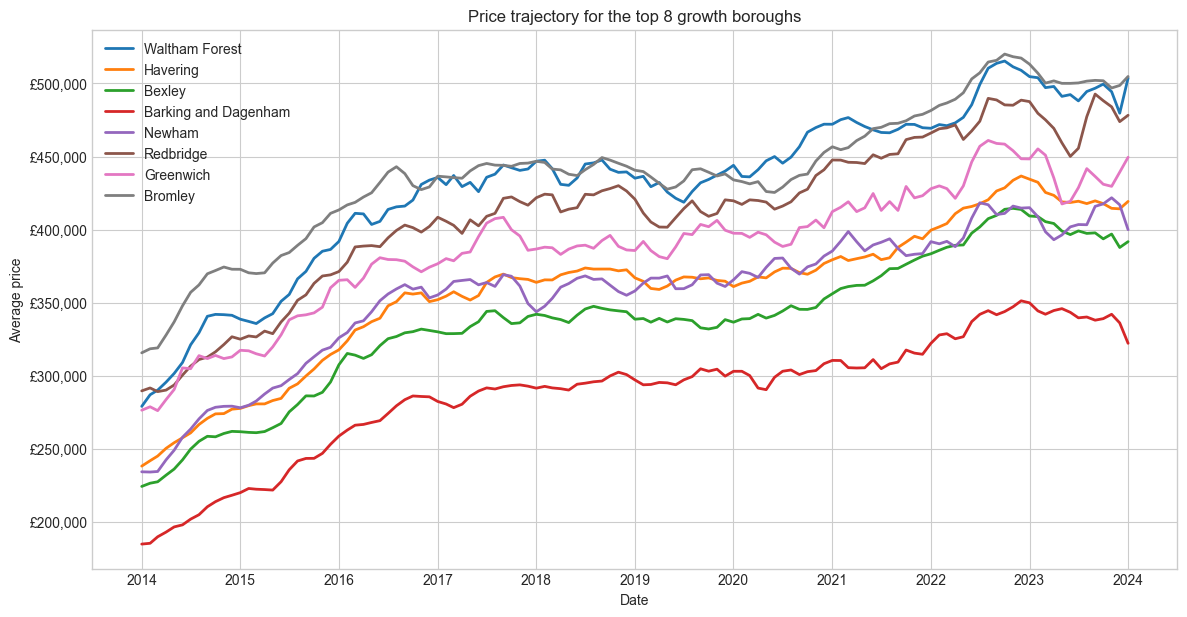

In [48]:
colors = plt.cm.tab10.colors  # 10 maximally distinct colours

fig, ax = plt.subplots(figsize=(14, 7))

for i, borough in enumerate(top_8):
    data = df_chart1[df_chart1['area_name'] == borough]
    ax.plot(data['date'], data['average_price'], label=borough, 
            color=colors[i], linewidth=2)
ax.set_title('Price trajectory for the top 8 growth boroughs')
ax.set_xlabel('Date')
ax.set_ylabel('Average price')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'£{x:,.0f}'))
ax.legend()
plt.savefig('../outputs/figures/chart1_price_trajectory.png', dpi=150, bbox_inches='tight')
plt.show()

**Chart 1 — Key observations:**
- **2014–2019:** Steady price divergence — Outer East boroughs begin outpacing Inner London peers on growth rate
- **2021–2022:** The post-COVID demand surge — a sharp upward inflection across all 8 boroughs simultaneously
- **2023:** The Bank of England rate-cycle correction — all 8 boroughs pull back from pandemic highs
- **Barking & Dagenham** remains the cheapest borough throughout the full decade, maintaining the largest headroom for future capital appreciation


### 4.2 Chart 2 — CAGR Ranking: All 32 Boroughs

Horizontal bar chart ranking all 32 boroughs by 10-year CAGR. Teal bars = above London average (3.77%); red = below. Every borough is labelled so a reader can locate any specific area immediately.


In [49]:
df_chart2 = df_master[['area_name','cagr_10yr']].sort_values( by = 'cagr_10yr', ascending = False).reset_index(drop=True)
print(df_chart2.head(3))


        area_name  cagr_10yr
0  Waltham Forest   0.060826
1        Havering   0.058166
2          Bexley   0.057347


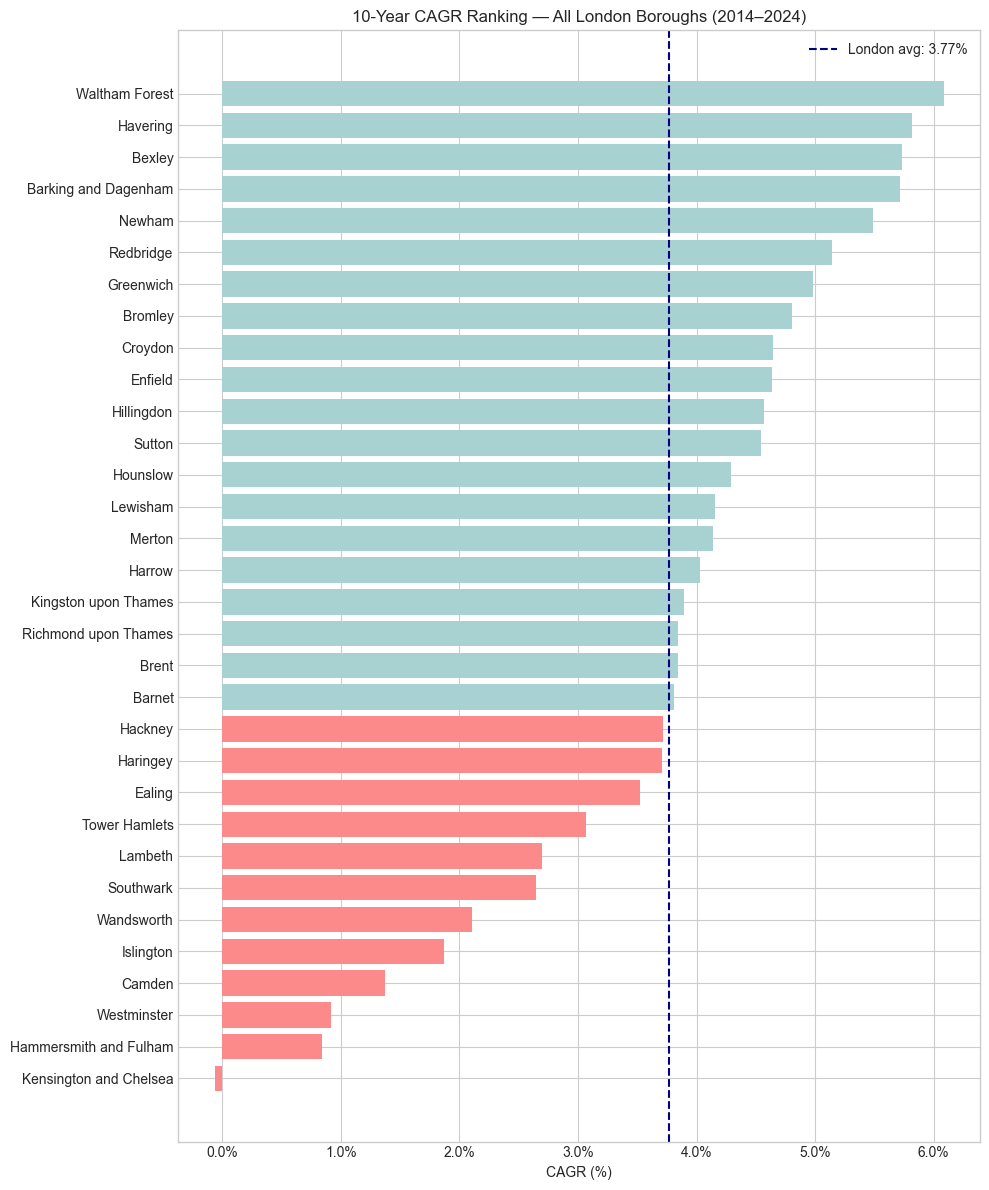

In [50]:
df_chart2 = df_chart2.sort_values('cagr_10yr', ascending=True).reset_index(drop=True)
avg_cagr = df_chart2['cagr_10yr'].mean()
colors = ['#a8d1d1' if v > avg_cagr else '#fd8a8a' for v in df_chart2['cagr_10yr']]

fig, ax = plt.subplots(figsize=(10, 12))
ax.barh(df_chart2['area_name'], df_chart2['cagr_10yr'], color=colors)
ax.axvline(avg_cagr, color='navy', linestyle='--', linewidth=1.5, label=f'London avg: {avg_cagr*100:.2f}%')
ax.set_title('10-Year CAGR Ranking — All London Boroughs (2014–2024)')
ax.set_xlabel('CAGR (%)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x*100:.1f}%'))

ax.legend()
plt.tight_layout()
plt.savefig('../outputs/figures/chart2_cagr_ranking.png', dpi=150, bbox_inches='tight')
plt.show()


**Chart 2 — Key observations:**
- The top 10 bars are all teal (above London average 3.77%) — all Outer London boroughs
- The bottom 5 bars (red, below average) are all Inner London: Kensington & Chelsea, Hammersmith & Fulham, Westminster, Camden, Islington
- Kensington & Chelsea sits at near-zero CAGR despite its reputation as London’s most prestigious borough
- The visual makes the investment thesis undeniable: prestige and returns are inversely correlated

### 4.3 Chart 3 — Crime vs Price Quadrant Scatter

Each dot represents one borough. X-axis = 2024 entry price; Y-axis = average annual crimes (2020–2024); dot colour = 10-year CAGR (green = high, red = low). Four investment quadrants are labelled. This chart captures the entire investment thesis in a single visual.


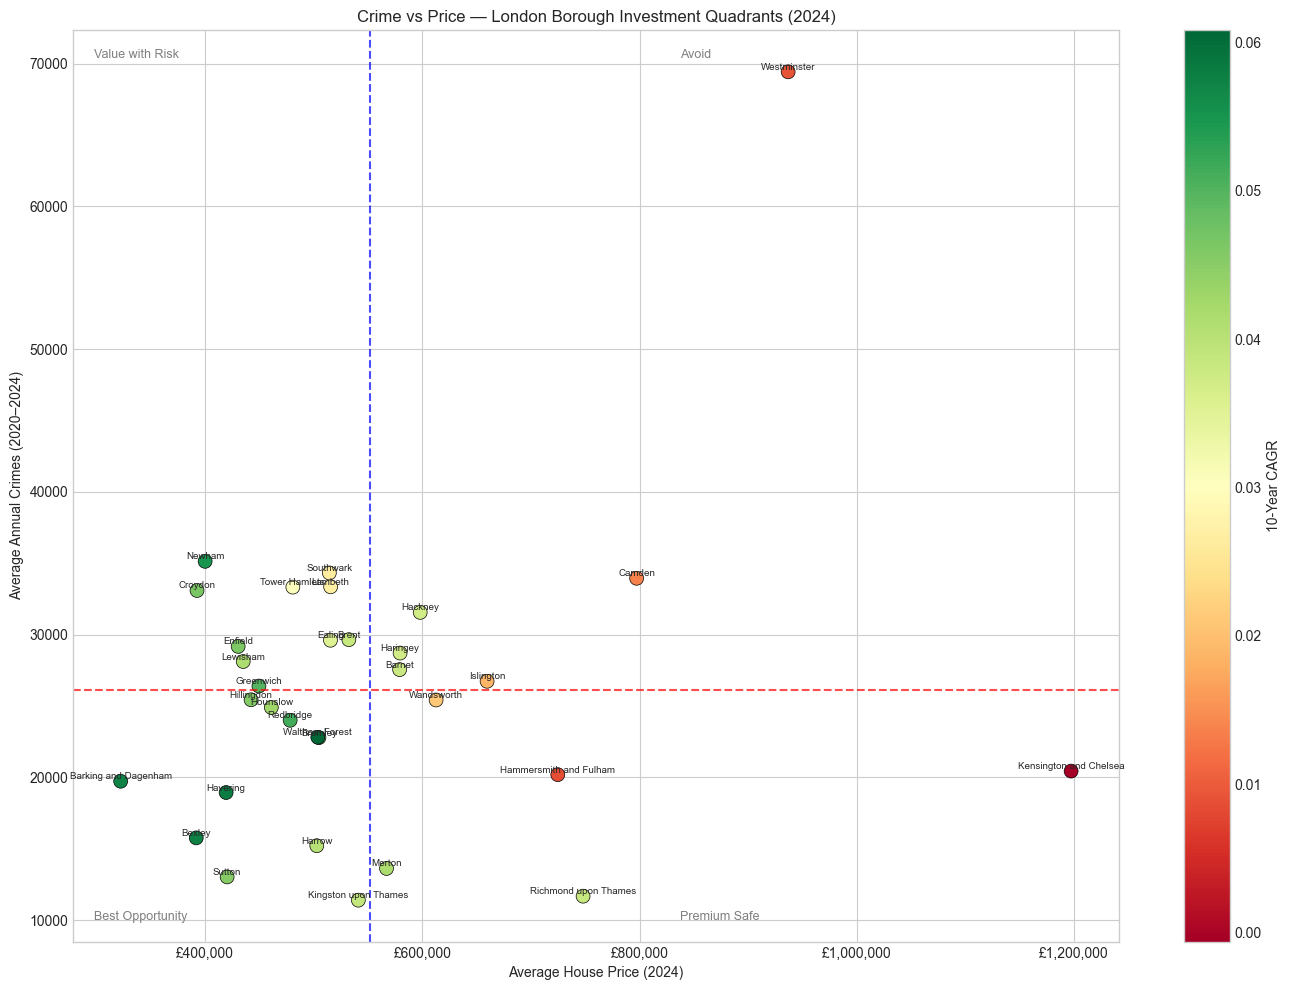

In [51]:
fig, ax = plt.subplots(figsize=(14, 10))

scatter = ax.scatter(
    x = df_master['price_2024'],        # x-axis: price
    y = df_master['avg_annual_crimes'],        # y-axis: crime
    c = df_master['cagr_10yr'],        # colour by: growth
    cmap = 'RdYlGn',            # red = low CAGR, green = high CAGR
    s = 100,                    # dot size
    edgecolors = 'black',
    linewidth = 0.5
)

plt.colorbar(scatter, ax=ax, label='10-Year CAGR')
avg_price = df_master['price_2024'].mean()
avg_crime = df_master['avg_annual_crimes'].mean()

ax.axvline(avg_price, color='blue', linestyle='--', alpha=0.7)
ax.axhline(avg_crime, color='red', linestyle='--', alpha=0.7)

for _, row in df_master.iterrows():
    ax.annotate(row['area_name'], 
                (row['price_2024'], row['avg_annual_crimes']),
                fontsize=7, ha='center', va='bottom')

ax.set_title('Crime vs Price — London Borough Investment Quadrants (2024)')
ax.set_xlabel('Average House Price (2024)')
ax.set_ylabel('Average Annual Crimes (2020–2024)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'£{x:,.0f}'))

ax.text(0.02, 0.98, 'Value with Risk', transform=ax.transAxes, fontsize=9, color='gray', va='top')
ax.text(0.58, 0.98, 'Avoid', transform=ax.transAxes, fontsize=9, color='gray', va='top')
ax.text(0.02, 0.02, 'Best Opportunity', transform=ax.transAxes, fontsize=9, color='gray', va='bottom')
ax.text(0.58, 0.02, 'Premium Safe', transform=ax.transAxes, fontsize=9, color='gray', va='bottom')

plt.tight_layout()
plt.savefig('../outputs/figures/chart3_crime_price_quadrant.png', dpi=150, bbox_inches='tight')
plt.show()


**Chart 3 — Key observations:**
- Green dots (high CAGR) cluster in the **bottom-left quadrant** — affordable and safe boroughs
- Red dots (low CAGR) dominate the **right half** — expensive London underperforms regardless of crime level
- Westminster sits upper-right (expensive AND high-crime) — coloured red, confirming AVOID status
- **The investment case in one visual:** growth is in affordable London, not expensive London


### 4.4 Chart 4 — Price Distributions: Inner vs Outer London

Two-panel chart: (left) 2024 house price box plot by Inner/Outer classification; (right) histogram of 10-year CAGR distribution across all 32 boroughs. Quantifies the Outer London price and growth advantage.


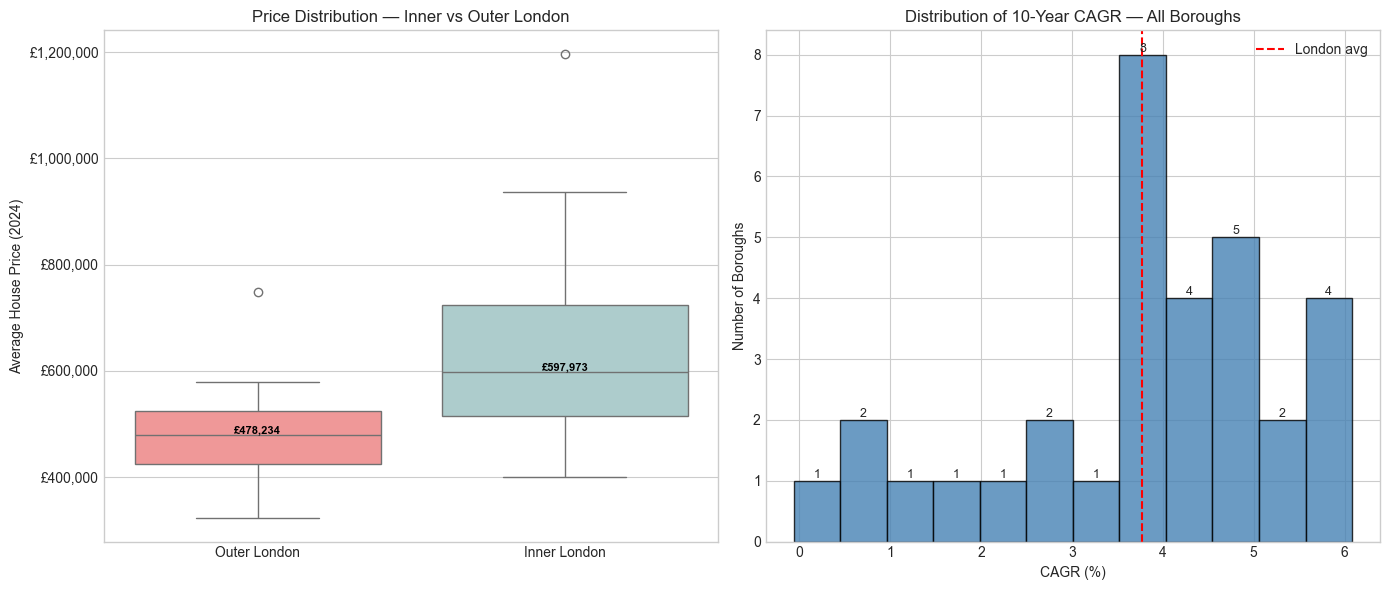

In [52]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
sns.boxplot(data=df_master, x='inner_outer_london', y='price_2024',
            hue='inner_outer_london', palette=['#fd8a8a', '#a8d1d1'], legend=False, ax=ax1)
ax1.set_title('Price Distribution — Inner vs Outer London')
ax1.set_xlabel('')
ax1.set_ylabel('Average House Price (2024)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'£{x:,.0f}'))

categories = [t.get_text() for t in ax1.get_xticklabels()]
for i, cat in enumerate(categories):
    median = df_master[df_master['inner_outer_london'] == cat]['price_2024'].median()
    ax1.text(i, median, f'£{median:,.0f}', ha='center', va='bottom',
             fontsize=8, fontweight='bold', color='black')

ax2.hist(df_master['cagr_10yr'] * 100, bins=12, color='steelblue', 
         edgecolor='black', alpha=0.8)
ax2.axvline(df_master['cagr_10yr'].mean() * 100, color='red', linestyle='--', linewidth=1.5, label='London avg')
ax2.set_title('Distribution of 10-Year CAGR — All Boroughs')
ax2.set_xlabel('CAGR (%)')
ax2.set_ylabel('Number of Boroughs')
ax2.legend()

for rect in ax2.patches:
    height = rect.get_height()
    if height > 0:
        ax2.text(rect.get_x() + rect.get_width()/2., height,
                 f'{int(height)}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/figures/chart4_price_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


**Chart 4 — Key observations:**
- **Box plot (left):** Outer London median price £478k vs Inner London £598k — a 25% entry price discount
- The Outer London interquartile range is tighter, indicating more homogeneous pricing across Outer boroughs
- **CAGR histogram (right):** The distribution is right-skewed — a cluster of boroughs in the 4–5% band with a long tail to the right (Waltham Forest at 6.08%)
- London average CAGR (red line) sits at 3.77%, meaning the majority of boroughs are below average due to the high-CAGR outliers in Outer East


### 4.5 Chart 5 — Investment Factor Correlation Matrix

Heatmap of pairwise Pearson correlations across 7 investment variables: price, CAGR, crime, unemployment, household income, qualifications, and PTAL transport score. Reveals the structural relationships underpinning the investment thesis.


In [53]:
# Step 1 - extract and rename

socio_cols = ['Area name', 
              'Unemployment rate (2014)',
              'Modelled Household median income estimates 2012/13',
              'Proportion of working age people with no qualifications (%) 2014',
              'Average Public Transport Accessibility score, 2014'
]

df_socio = df_profiles[df_profiles['Inner/ Outer London'].isin(['Inner London', 'Outer London'])][socio_cols].copy()

df_socio = df_socio.rename(columns={
    'Area name': 'area_name',
    'Unemployment rate (2014)': 'unemployment_rate',
    'Modelled Household median income estimates 2012/13': 'median_income',
    'Proportion of working age people with no qualifications (%) 2014': 'no_qualifications_pct',
    'Average Public Transport Accessibility score, 2014': 'ptal_score'
})

print(df_socio.shape)


(33, 5)


In [54]:
df_corr = df_master.merge(df_socio, on='area_name', how='left')
print(df_corr.shape)
print(df_corr.isna().sum())

(32, 13)
area_code                   0
area_name                   0
inner_outer_london          0
population_estimate_2015    0
price_2014                  0
price_2024                  0
cagr_10yr                   0
total_crimes_2020_2024      0
avg_annual_crimes           0
unemployment_rate           0
median_income               0
no_qualifications_pct       0
ptal_score                  0
dtype: int64


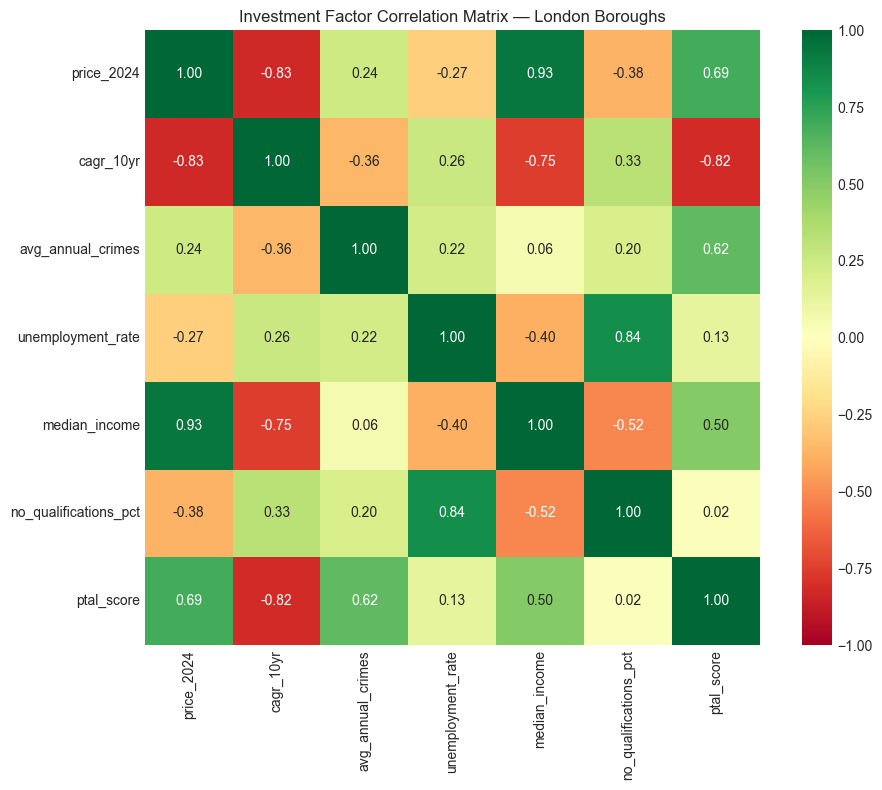

In [55]:
corr_cols = ['price_2024', 'cagr_10yr', 'avg_annual_crimes', 
             'unemployment_rate', 'median_income', 'no_qualifications_pct', 'ptal_score']

corr_matrix = df_corr[corr_cols].corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title('Investment Factor Correlation Matrix — London Boroughs')
plt.tight_layout()
plt.savefig('../outputs/figures/chart5_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

**Correlation Matrix — Investment Implications:**

| Correlation | Value | Investment Meaning |
|-------------|-------|--------------------|
| price_2024 ↔ cagr_10yr | **–0.83** | Expensive boroughs historically produce the worst returns |
| price_2024 ↔ median_income | **+0.93** | Price follows income geography, not crime levels |
| cagr_10yr ↔ ptal_score | **–0.82** | Well-connected boroughs are already priced in — no upside remains |
| unemployment ↔ price_2024 | negative | Higher unemployment areas are cheaper with higher CAGR potential |

**Key insight:** Transport access and prestige are fully capitalised into current prices. Value and growth lie in the boroughs that income data says are *catching up* — not the ones that have already arrived.


### 4.6 Chart 6 — Crime Trend for Top Investment Boroughs (Jun 2020–May 2026)

Monthly crime totals for the 6 highest-scored investment boroughs. Distinguishes boroughs with improving safety trajectories from those with elevated or rising crime — a critical risk factor for the HOLD vs BUY decision.


In [56]:
target_6 = ['Waltham Forest', 'Havering', 'Bexley', 
             'Barking and Dagenham', 'Newham', 'Redbridge']

df_chart6 = df_crime_all[df_crime_all['area_name'].isin(target_6)].groupby(['area_name','date'])['crimes'].sum().reset_index()
print(df_chart6.shape)

(432, 3)


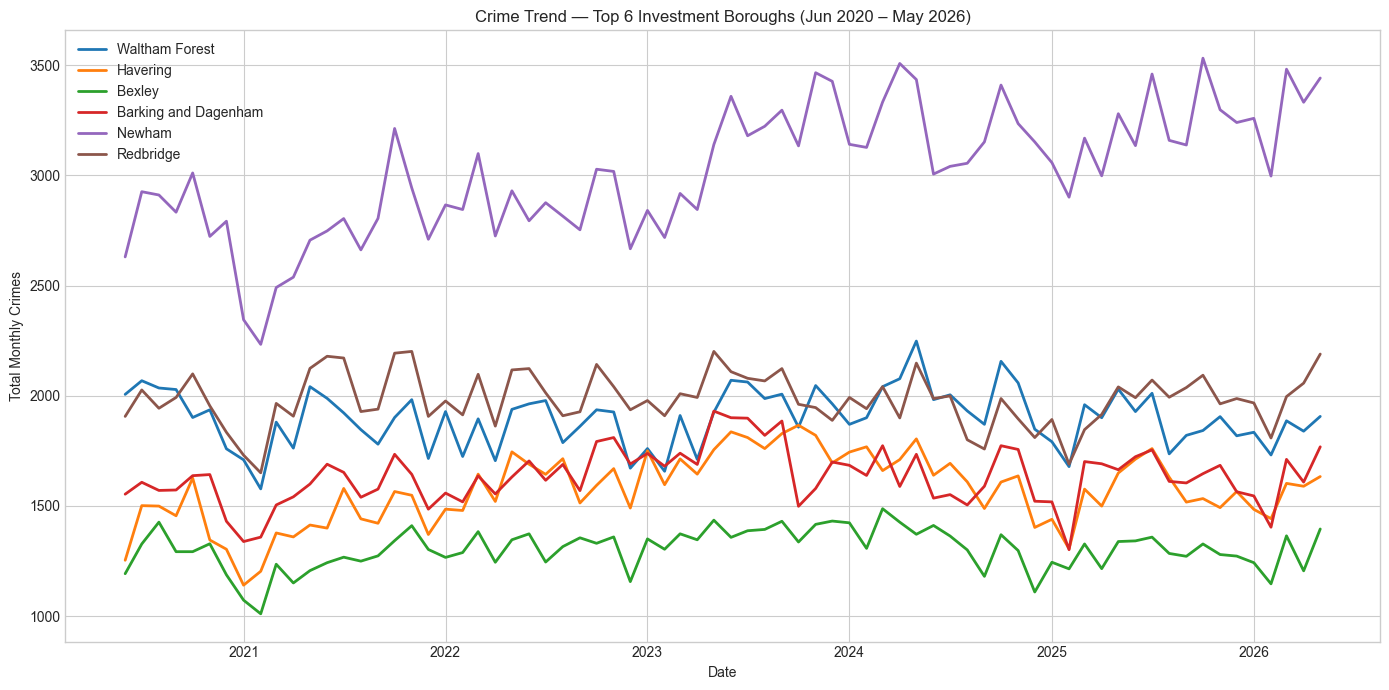

In [57]:
colors = plt.cm.tab10.colors

fig, ax = plt.subplots(figsize=(14, 7))
for i, borough in enumerate(target_6):
    data = df_chart6[df_chart6['area_name']==borough]
    ax.plot(data['date'], data['crimes'], label=borough, color=colors[i], linewidth=2)

ax.set_title('Crime Trend — Top 6 Investment Boroughs (Jun 2020 – May 2026)')
ax.set_xlabel('Date')
ax.set_ylabel('Total Monthly Crimes')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/figures/chart6_crime_trend.png', dpi=150, bbox_inches='tight')
plt.show()

**Chart 6 — Key observations:**
- **Bexley** — consistently the lowest crime of all 6 boroughs, with a slight downward trend; safest entry in this group
- **Havering** — second lowest, relatively flat; quiet residential borough with stable safety metrics
- **Newham** — highest crime by a wide margin with an upward trend since 2022; strong CAGR but elevated and rising crime justifies HOLD rather than BUY
- The 2020–2021 dip across all boroughs reflects COVID lockdown suppression, not structural safety improvement


### Section 4 — Visualisations Summary

| Chart | Visual Type | Key Finding Shown |
|-------|-------------|-------------------|
| Chart 1 | Line — Price Trajectory | Post-COVID surge and 2023 rate correction clearly visible in all 8 boroughs |
| Chart 2 | Bar — CAGR Ranking | Outer East cluster dominates the top 10; all bottom 5 are Inner London |
| Chart 3 | Scatter — Crime vs Price | Green dots (high CAGR) cluster bottom-left; red dots dominate expensive London |
| Chart 4 | Box + Histogram | Outer London: £478k median vs Inner London £598k; broader CAGR distribution |
| Chart 5 | Heatmap — Correlations | –0.83 price/CAGR correlation is the model's statistical foundation |
| Chart 6 | Line — Crime Trends | Bexley and Havering improving; Newham elevated and trending up |
| Chart 7 | Bar — Score Ranking | All 5 BUY boroughs are Outer London; all 5 AVOID are Inner London |

All 7 charts saved to `outputs/figures/` at 150 DPI.

## 5. Investment Scoring Model

The scoring model translates three raw metrics into a single comparable 0–100 score for each of the 32 boroughs. Each component is independently min-max normalised before combining.

**Weight rationale:**
- **Growth (40%)** — primary return driver; highest weight reflects capital appreciation as the core investment objective
- **Safety (30%)** — crime reduction precedes buyer demand and price appreciation; a leading indicator
- **Affordability (30%)** — entry-point risk and headroom for capital gains; lower entry = more upside


**Min-max normalisation formula:**

For metrics where *higher is better* (e.g. CAGR → growth score):
```
score = (value – min) / (max – min) × 100
```

For metrics where *lower is better* (crime → safety score; price → affordability score), the formula is inverted:
```
score = (max – value) / (max – min) × 100
```

This ensures all three component scores run on the same 0–100 scale (0 = worst-performing borough, 100 = best-performing borough) before the weighted average is applied.


In [58]:
df_scored = df_master.copy()

df_scored['growth_score'] = (df_scored['cagr_10yr'] - df_scored['cagr_10yr'].min()) / (df_scored['cagr_10yr'].max() - df_scored['cagr_10yr'].min()) * 100

df_scored['safety_score'] = (df_scored['avg_annual_crimes'].max() - df_scored['avg_annual_crimes']) / ((df_scored['avg_annual_crimes'].max() - df_scored['avg_annual_crimes'].min())) * 100 # inverted
df_scored['afford_score'] = (df_scored['price_2024'].max() - df_scored['price_2024']) / ((df_scored['price_2024'].max() - df_scored['price_2024'].min()) ) * 100 # inverted
print(df_scored[['area_name', 'growth_score', 'safety_score', 'afford_score']].head())

              area_name  growth_score  safety_score  afford_score
0  Barking and Dagenham     93.974438     85.642097    100.000000
1                Barnet     63.021257     72.167751     70.651373
2                Bexley     94.339483     92.480076     92.050321
3                 Brent     63.494961     68.552104     75.994738
4               Bromley     79.202985     80.380390     79.138520


Investment Score = Growth Score × 0.40
                + Safety Score × 0.30
                + Affordability Score × 0.30

In [59]:
df_scored['investment_score'] = (
    df_scored['growth_score'] * 0.40 +
    df_scored['safety_score'] * 0.30 +
    df_scored['afford_score'] * 0.30
)


df_scored.head()

,area_code,area_name,inner_outer_london,population_estimate_2015,price_2014,price_2024,cagr_10yr,total_crimes_2020_2024,avg_annual_crimes,growth_score,safety_score,afford_score,investment_score
0,E09000002,Barking and Dagenham,Outer London,203600,184883.6549,322220.0,0.057123,78906.0,19726.50,93.974438,85.642097,100.000000,93.282404
1,E09000003,Barnet,Outer London,383100,398384.3422,579029.0,0.038101,110184.0,27546.00,63.021257,72.167751,70.651373,68.054240
2,E09000004,Bexley,Outer London,240600,224320.5222,391782.0,0.057347,63033.0,15758.25,94.339483,92.480076,92.050321,93.094912
3,E09000005,Brent,Outer London,325300,365189.8763,532273.0,0.038393,118577.0,29644.25,63.494961,68.552104,75.994738,68.762037
4,E09000006,Bromley,Outer London,324600,315709.3226,504764.0,0.048045,91120.0,22780.00,79.202985,80.380390,79.138520,79.536867


In [60]:
df_scored.to_sql('scores', conn, if_exists='replace', index=False)
print("Score table ready.")

Score table ready.


In [61]:
query = """
SELECT area_name, investment_score
FROM scores
ORDER BY investment_score DESC
LIMIT 5
"""

pd.read_sql(query, conn)

,area_name,investment_score
0,Barking and Dagenham,93.282404
1,Bexley,93.094912
2,Havering,91.042442
3,Waltham Forest,87.876601
4,Sutton,85.788468


In [62]:
df_scored = df_scored.sort_values('investment_score', ascending=False).reset_index(drop=True)

def assign_signal(rank):
    """Map an investment-score rank (0 = best) to a BUY/HOLD/AVOID signal.

    Top 5 boroughs by score are BUY, bottom 5 are AVOID, everything
    in between is HOLD.
    """
    if rank < 5:
        return 'BUY'
    elif rank >= len(df_scored) - 5:
        return 'AVOID'
    else:
        return 'HOLD'

df_scored['signal'] = df_scored.index.map(assign_signal)

print(df_scored[['area_name', 'investment_score', 'signal']])

                 area_name  investment_score signal
0     Barking and Dagenham         93.282404    BUY
1                   Bexley         93.094912    BUY
2                 Havering         91.042442    BUY
3           Waltham Forest         87.876601    BUY
4                   Sutton         85.788468    BUY
5                Redbridge         82.006791   HOLD
6                   Newham         81.215655   HOLD
7                Greenwich         80.712112   HOLD
8                  Bromley         79.536867   HOLD
9               Hillingdon         78.780324   HOLD
10                  Harrow         78.494929   HOLD
11    Kingston upon Thames         78.240569   HOLD
12                  Merton         77.824399   HOLD
13                 Enfield         77.708082   HOLD
14                 Croydon         77.003195   HOLD
15                Hounslow         76.576244   HOLD
16                Lewisham         74.933329   HOLD
17    Richmond upon Thames         70.685864   HOLD
18          

**Signal interpretation:**
- **BUY (top 5, score ≥ 85):** Strong across all three dimensions simultaneously
- **HOLD (22 boroughs):** Acceptable risk/return but not compelling on all three axes at once
- **AVOID (bottom 5, score ≤ 53):** All five are Inner London boroughs — high entry price and weak growth or high crime combine to produce the worst investment profile in London

This is the model's most counter-intuitive result: the boroughs most investors *assume* are safe bets — Kensington, Westminster, Hammersmith — are statistically the worst 10-year performers.

### 5.1 Chart 7 — Investment Score Ranking: All 32 Boroughs

The final chart visualises the complete borough ranking with BUY/HOLD/AVOID colour coding. This is the deliverable — a single chart an investor can use to identify target boroughs and compare their relative composite score at a glance.


In [63]:
signal_colors = {
    'BUY': '#B4CDC9',
    'HOLD': '#E9EDC9',
    'AVOID': '#FFC8BD'
}

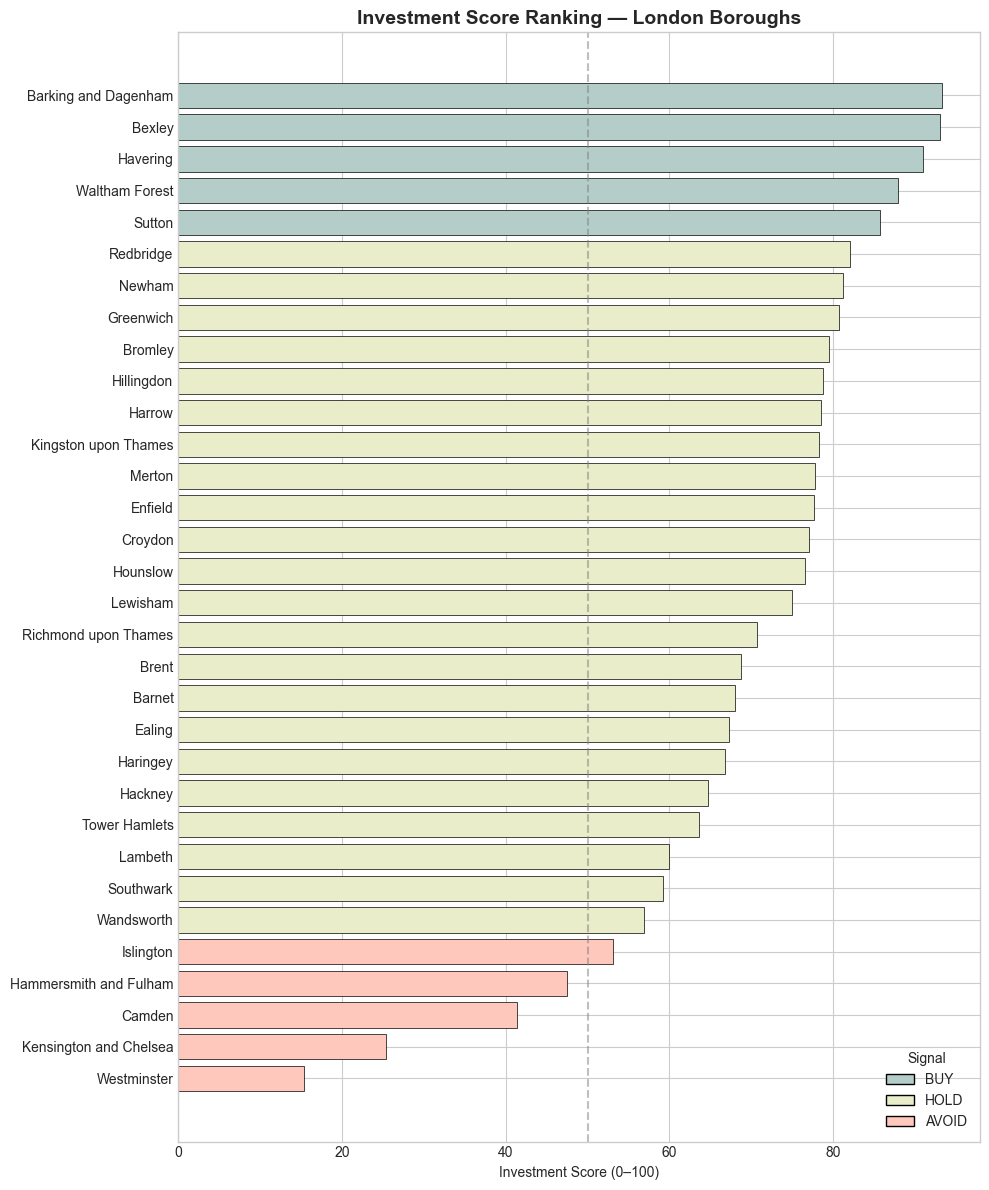

In [64]:
df_chart7 = df_scored.sort_values('investment_score', ascending=True)
colors_7 = [signal_colors[s] for s in df_chart7['signal']]
fig, ax = plt.subplots(figsize=(10, 12))
bars = ax.barh(df_chart7['area_name'], df_chart7['investment_score'], color=colors_7, edgecolor='black', linewidth=0.5)


ax.set_title('Investment Score Ranking — London Boroughs', fontsize=14, fontweight='bold')
ax.set_xlabel('Investment Score (0–100)')
ax.axvline(50, color='gray', linestyle='--', alpha=0.5)

for signal, color in signal_colors.items():
    ax.barh([], [], color=color, edgecolor='black', linewidth=0.5, label=signal)
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=signal_colors['BUY'], edgecolor='black', label='BUY'),
                   Patch(facecolor=signal_colors['HOLD'], edgecolor='black', label='HOLD'),
                   Patch(facecolor=signal_colors['AVOID'], edgecolor='black', label='AVOID')]
ax.legend(handles=legend_elements, title='Signal', loc='lower right')
plt.tight_layout()
plt.savefig('../outputs/figures/chart7_investment_ranking.png', dpi=150, bbox_inches='tight')
plt.show()


**Chart 7 — Key observations:**
- All 5 BUY boroughs are Outer London; all 5 AVOID boroughs are Inner London — the model confirms the spatial pattern revealed throughout the SQL analysis
- The score gap between BUY and AVOID is approximately 70 points — these are not marginal distinctions; they reflect fundamentally different investment profiles
- Westminster (15.3) and Kensington & Chelsea (25.3) score at the very bottom despite their premium reputations, validating the counter-intuitive core finding of this analysis
- The HOLD band (scores 40–80) is wide, confirming most boroughs are reasonable long-term holds but not compelling across all three axes simultaneously


### 5.2 Save Final Outputs

The scored and ranked dataset is saved to `data/processed/` for use by the Streamlit dashboard. The full price history is also saved to enable the interactive price trajectory chart per borough.


In [65]:
df_scored.to_csv('../data/processed/borough_investment_scores.csv', index=False)
print("Saved.")

Saved.


In [66]:
df_prices_clean.to_csv('../data/processed/price_history_london.csv', index=False)
print("Saved.")

Saved.


---

## Overall Conclusions

### Key Findings

- **Growth is in affordable Outer London, not prestigious Inner London.** A –0.83 Pearson correlation between 2024 entry price and 10-year CAGR across all 32 boroughs is the strongest quantitative signal in the dataset. The more expensive the borough, the worse the historical return.

- **Top 3 BUY boroughs — Barking & Dagenham (93.3), Bexley (93.1), Havering (91.0).** All Outer London. All priced 20–37% below the London median. All with 5-year average annual crime below 20,000. All with 10-year CAGR above 5.7%.

- **Worst investments — Westminster (15.3) and Kensington & Chelsea (25.3).** Westminster's low score comes from the highest crime volume in the dataset combined with a high entry price, not weak growth (its 10-year CAGR is +0.92%). Kensington & Chelsea is the genuine growth laggard, with a flat –0.06% 10-year CAGR despite an entry price above £1.19M.

- **The Alpha Zone contains 17 of 32 boroughs** — offering above-average CAGR AND below-average entry price simultaneously. This structural mispricing is the core investment opportunity this analysis identifies.

- **Outer London dominates all three investment dimensions simultaneously:** 25% cheaper average entry price (£484k vs £650k), 85% higher average 10-year CAGR, and lower average annual crime than Inner London.

- **29 of 32 boroughs recorded negative 12-month price growth to January 2024** — a market-wide correction driven by the Bank of England rate cycle. For high-CAGR Outer London boroughs with strong 10-year fundamentals, this correction creates an improved entry point relative to long-run trajectory.

- **Crime is a risk filter, not a return driver.** The price/CAGR correlation of –0.83 overwhelms any crime/price relationship. Investors can find safer *and* cheaper boroughs with better growth rates than Inner London alternatives.

### Business Implications

A property investor applying this model would concentrate capital in Outer East London (Barking & Dagenham, Bexley, Havering, Waltham Forest) and avoid Inner London prestige markets. The 2023–2024 price correction in these boroughs has improved entry valuations relative to their 10-year compounding trajectory.

### Limitations

1. **CAGR uses a single point-in-time comparison** (Jan 2014 vs Jan 2024), so it is sensitive to which exact month you pick. A rolling 12-month average would smooth this out.
2. **Crime data aggregates all crime categories** — robbery, theft, violence, and anti-social behaviour have different implications for residential demand and should be decomposed in a more advanced model.
3. **No forward-looking features** — regeneration projects (e.g. Barking Riverside), transport investment, and planning approvals are not captured in historical price data but are strong leading indicators.
4. **Socioeconomic data is from 2014** (GLA borough profiles vintage) — 10-year-old income and qualification figures may not reflect current demographic shifts in Outer London boroughs.

### Future Improvements

- Add rental yield data (Zoopla/Rightmove API) to compute total return = capital gain + rental income
- Incorporate planning application volume as a forward-looking regeneration signal
- Build a time-series forecasting component (ARIMA or Prophet) to project 3-year price trajectories
- Decompose crime by category for a more granular safety score
- Add monthly transaction volume as a market liquidity signal — illiquid boroughs carry additional exit risk